# Imports and configs

In [ ]:
import os
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import yaml
from IPython.display import display
from PIL import Image, ImageDraw
from tqdm.auto import tqdm


In [15]:
DATA_CONFIGURATION = yaml.safe_load(
    Path("/workspaces/WebIdentification/cv_webidentification.yaml").read_text()
)
ROOT_DIR = Path("/workspaces/WebIdentification")
DATA_DIR = ROOT_DIR / DATA_CONFIGURATION["path"]
SPLITS = ["train", "val", "test"]

# Check for BBOX variation
We want to check for the following variations in the bounding boxes.
- Place in image
- Size in image
- Class distribution
- Average bbox per image
- Corruputed images

### The following sections are checks for corrupted images in a variety of ways. This can be duplicate labels, or non-normalized images. We can add more checks here as we find more ways that the data is corrupted.

In [16]:
@dataclass
class BBox:
    class_id: int
    x_center: float
    y_center: float
    width: float
    height: float


label_hash = {}
bboxs = {}
line_hash_to_images = {}

for split in SPLITS:
    label_paths = list((DATA_DIR / split).glob("*.txt"))
    bboxs[split] = []
    for label_path in label_paths:
        with open(label_path) as f:
            lines = [line.strip() for line in f if line.strip()]
        for line in lines:
            class_id, x_center, y_center, width, height = line.split()
            bboxs[split].append(
            BBox(
                int(class_id),
                float(x_center),
                float(y_center),
                float(width),
                float(height),
            )
        )


In [18]:
num_labels = {}
duplicate_lines_within_image = {}
for split in SPLITS:
    label_paths = list((DATA_DIR / split).glob("*.txt"))
    label_hash[split] = set()
    duplicate_lines_within_image[split] = 0
    num_labels[split] = 0
    for label_path in label_paths:
        with open(label_path) as f:
            lines = [line.strip() for line in f if line.strip()]
        hashed_lines = set(lines)
        label_hash[split].add(frozenset(hashed_lines))
        duplicate_lines_within_image[split] += len(lines) - len(hashed_lines)
        if len(lines) == 0:
            print(f"Corrupted image found: {label_path.with_suffix('.png')}")
        num_labels[split] += len(lines)


In [19]:

for split in SPLITS:
    label_paths = list((DATA_DIR / split).glob("*.txt"))
    average_bbox_per_image = (
        num_labels[split] / len(label_paths)
    )
    print(f"Average bbox per image for {split}: {average_bbox_per_image:.3f}")
    print(
        f"Files with duplicate lines inside image for {split}: {duplicate_lines_within_image[split]} (/{len(label_paths)})"
    )
    

Average bbox per image for train: 21.583
Files with duplicate lines inside image for train: 66453 (/49538)
Average bbox per image for val: 19.662
Files with duplicate lines inside image for val: 249 (/7158)
Average bbox per image for test: 18.631
Files with duplicate lines inside image for test: 5163 (/25251)


### Show the distribution per split, 
note only buttons for now, but still gives an idea of numbers.

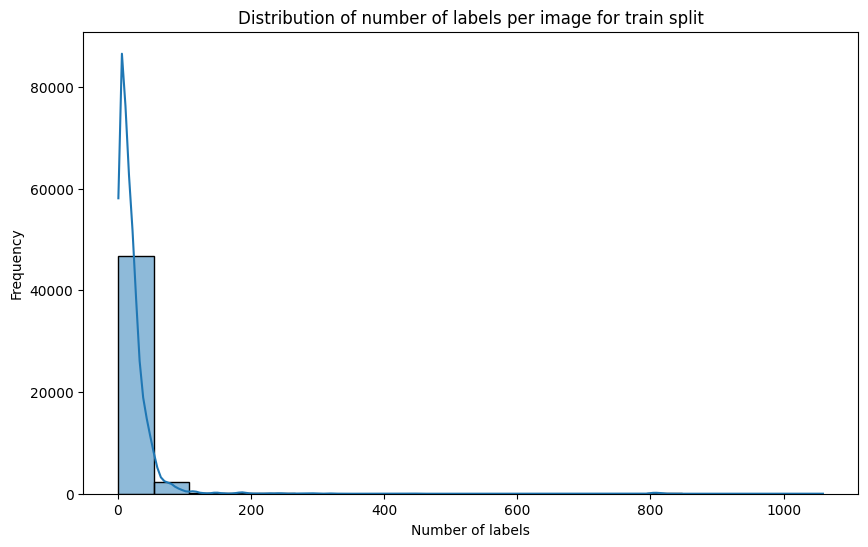

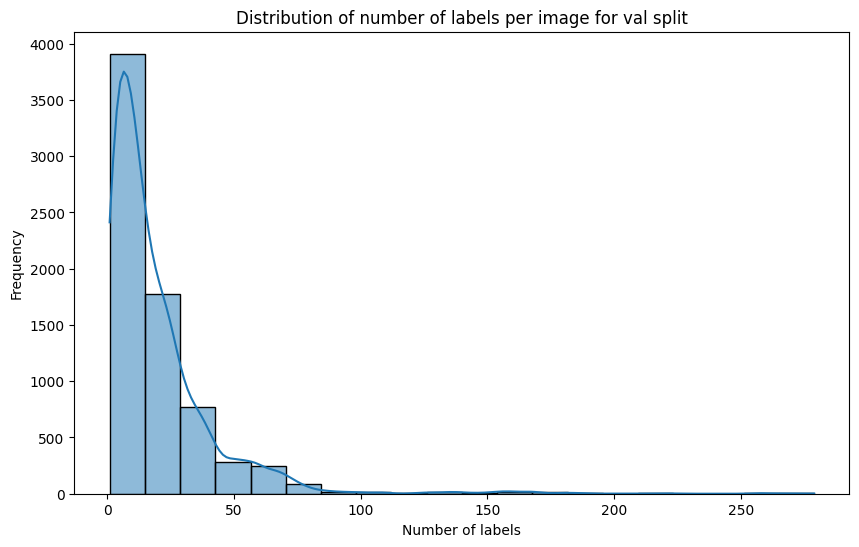

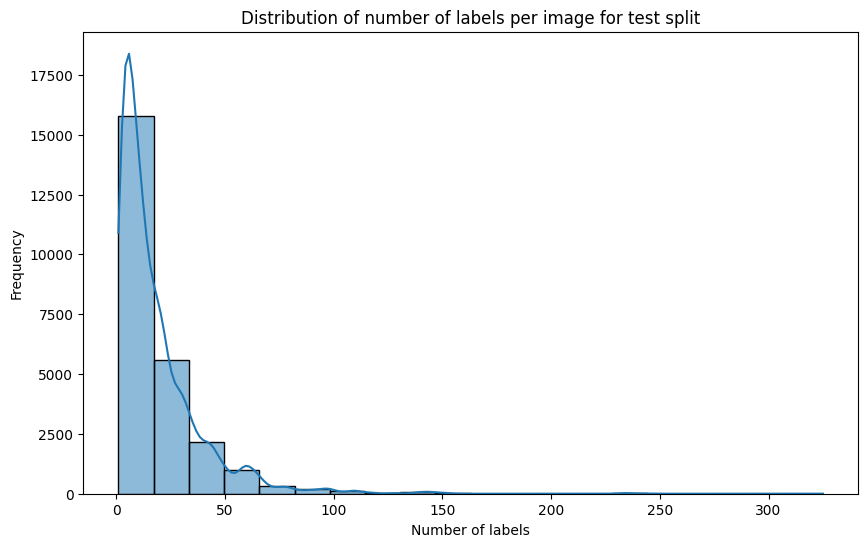

In [22]:
for split in SPLITS:
    plt.figure(figsize=(10, 6))
    labels_per_image = []
    for label_path in (DATA_DIR / split).glob("*.txt"):
        with open(label_path) as f:
            lines = [line.strip() for line in f if line.strip()]
            labels_per_image.append(len(lines))

    sns.histplot(labels_per_image, bins=20, kde=True)
    plt.title(f"Distribution of number of labels per image for {split} split")
    plt.xlabel("Number of labels")
    plt.ylabel("Frequency")
    plt.show()

### Show the distribution of where the bboxes are located in the image. 

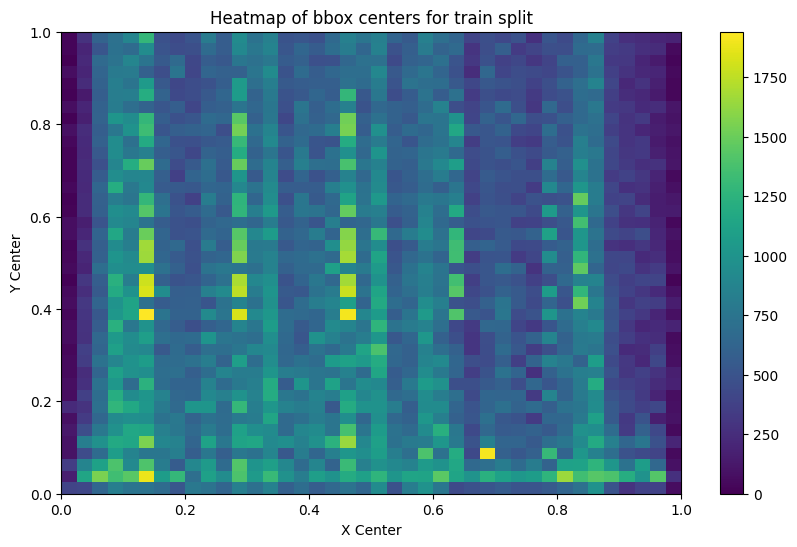

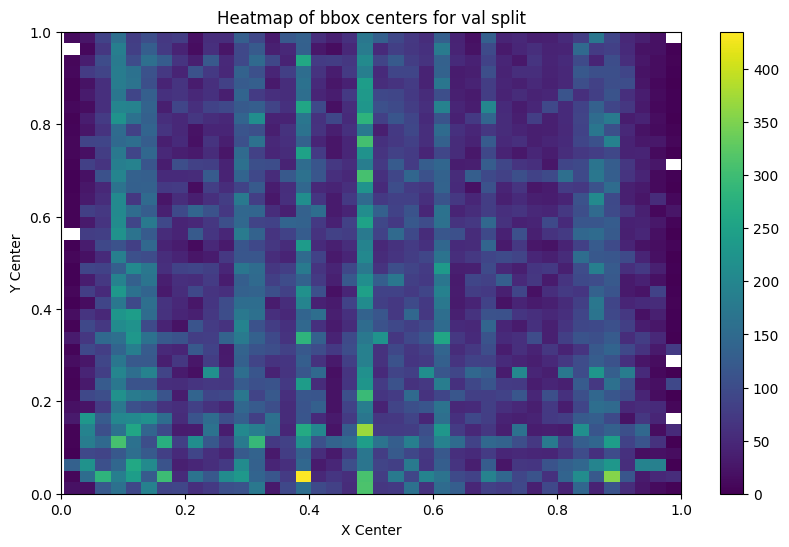

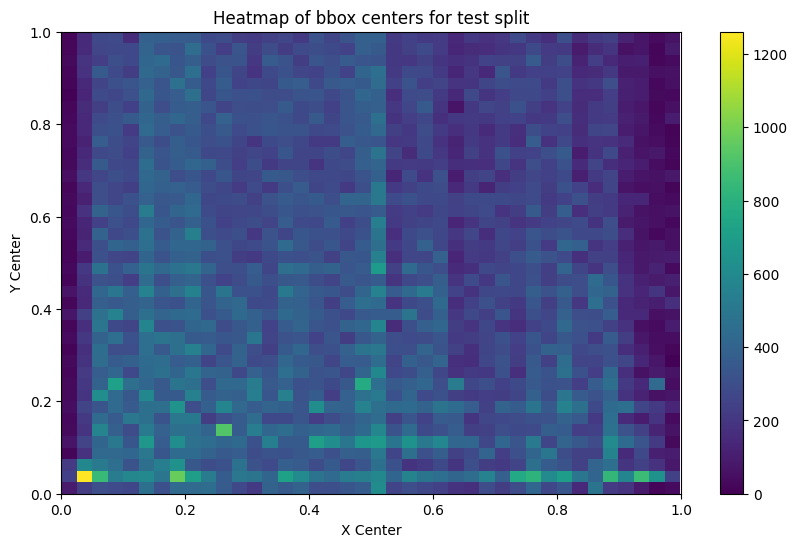

In [23]:
for split in SPLITS:
    x_centers = [bbox.x_center for bbox in bboxs[split]]
    y_centers = [bbox.y_center for bbox in bboxs[split]]

    plt.figure(figsize=(10, 6))
    sns.histplot(x=x_centers, y=y_centers, bins=40, cbar=True, cmap="viridis")
    plt.title(f"Heatmap of bbox centers for {split} split")
    plt.xlabel("X Center")
    plt.ylabel("Y Center")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

### Show the distribution of the bbox sizes in the image.

Note, shows them as if they were in the middle of the image, so we can see how big they are, but not where they are.

In [ ]:
IMG_W = 1920
IMG_H = 1080

for split in SPLITS:
    canvas = Image.new("RGB", (IMG_W, IMG_H), (18, 18, 24))
    draw = ImageDraw.Draw(canvas, "RGBA")

    for bbox in bboxs[split]:
        x_center = 0.5
        y_center = 0.5

        left = int((x_center - bbox.width / 2) * IMG_W)
        right = int((x_center + bbox.width / 2) * IMG_W)
        top = int((y_center - bbox.height / 2) * IMG_H)
        bottom = int((y_center + bbox.height / 2) * IMG_H)

        left = max(0, min(IMG_W, left))
        right = max(0, min(IMG_W, right))
        top = max(0, min(IMG_H, top))
        bottom = max(0, min(IMG_H, bottom))

        if right <= left or bottom <= top:
            continue

        draw.rectangle(
            [(left, top), (right - 1, bottom - 1)],
            outline=(255, 120, 40, 70),
            width=1,
        )

    center_x = IMG_W // 2
    center_y = IMG_H // 2
    draw.line([(center_x, 0), (center_x, IMG_H - 1)], fill=(80, 180, 255, 120), width=2)
    draw.line([(0, center_y), (IMG_W - 1, center_y)], fill=(80, 180, 255, 120), width=2)

    print(f"Centered bbox rectangles for {split} ({IMG_W}x{IMG_H})")
    display(canvas)

### Show "corrupted" data

In [24]:
zero_zero_counts = {}
total_zero_zero = 0

for split in SPLITS:
    count = sum(1 for bbox in bboxs[split] if bbox.width == 0.0 and bbox.height == 0.0)
    zero_zero_counts[split] = count
    total_zero_zero += count
    print(f"0x0 boxes in {split}: {count}")

print(f"Total 0x0 boxes across all splits: {total_zero_zero}")

0x0 boxes in train: 0
0x0 boxes in val: 0
0x0 boxes in test: 0
Total 0x0 boxes across all splits: 0


In [25]:
top_left_corner = {}
total_top_left_corner = 0

for split in SPLITS:
    count = sum(
        1 for bbox in bboxs[split] if bbox.x_center < 0.001 and bbox.y_center < 0.001
    )
    top_left_corner[split] = count
    total_top_left_corner += count
    print(f"boxes found in top left corner {split}: {count}")

print(f"Total boxes found in top left corner across all splits: {total_top_left_corner}")

boxes found in top left corner train: 0
boxes found in top left corner val: 0
boxes found in top left corner test: 0
Total boxes found in top left corner across all splits: 0


In [26]:
corner_counts = {}
total_corner = 0

for split in SPLITS:
    top_left_count = 0
    top_right_count = 0
    bottom_left_count = 0
    bottom_right_count = 0
    for bbox in bboxs[split]:
        in_top_left = bbox.x_center < 0.001 and bbox.y_center < 0.001
        in_top_right = bbox.x_center > 0.999 and bbox.y_center < 0.001
        in_bottom_left = bbox.x_center < 0.001 and bbox.y_center > 0.999
        in_bottom_right = bbox.x_center > 0.999 and bbox.y_center > 0.999
       
        if in_top_left:
            top_left_count += 1
        if in_top_right:
            top_right_count += 1
        if in_bottom_left:
            bottom_left_count += 1
        if in_bottom_right:
            bottom_right_count += 1

    corner_counts[split] = top_left_count + top_right_count + bottom_left_count + bottom_right_count
    total_corner += corner_counts[split]
    print(f"boxes found in all corners {split}: {corner_counts[split]}")

print(f"Total boxes found in all corners across all splits: {total_corner}")

boxes found in all corners train: 0
boxes found in all corners val: 0
boxes found in all corners test: 0
Total boxes found in all corners across all splits: 0


A concering amount of corner boxes was found, below is a script to get rid of them. It can be found in the tools folder as well.

```bash
python tools/remove_corner_boxes.py --dataset_path /path/to/dataset
```


### Show the distribution of colours in the bbox slices. 

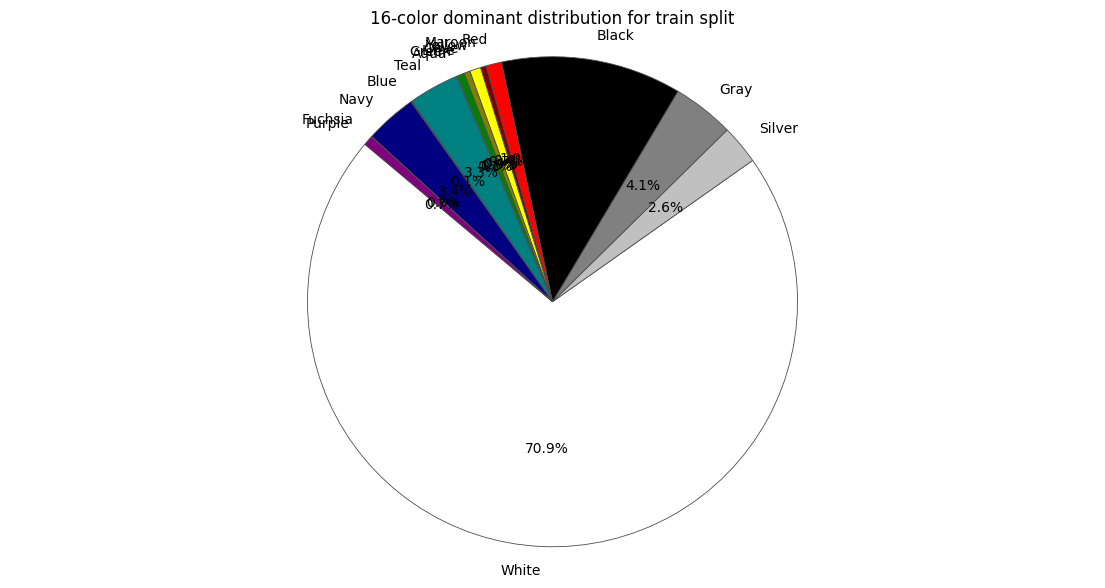

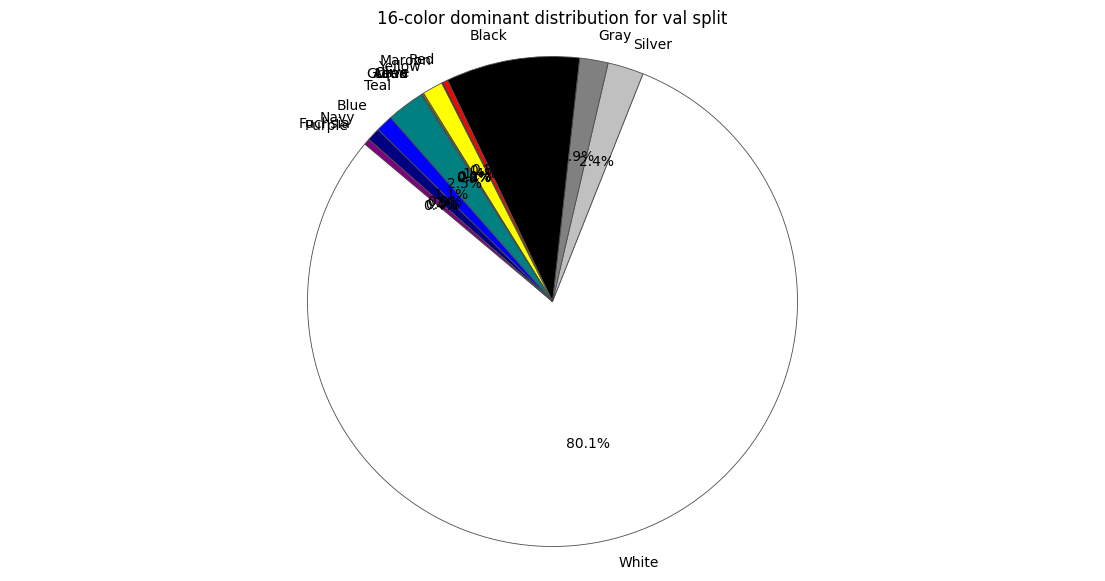

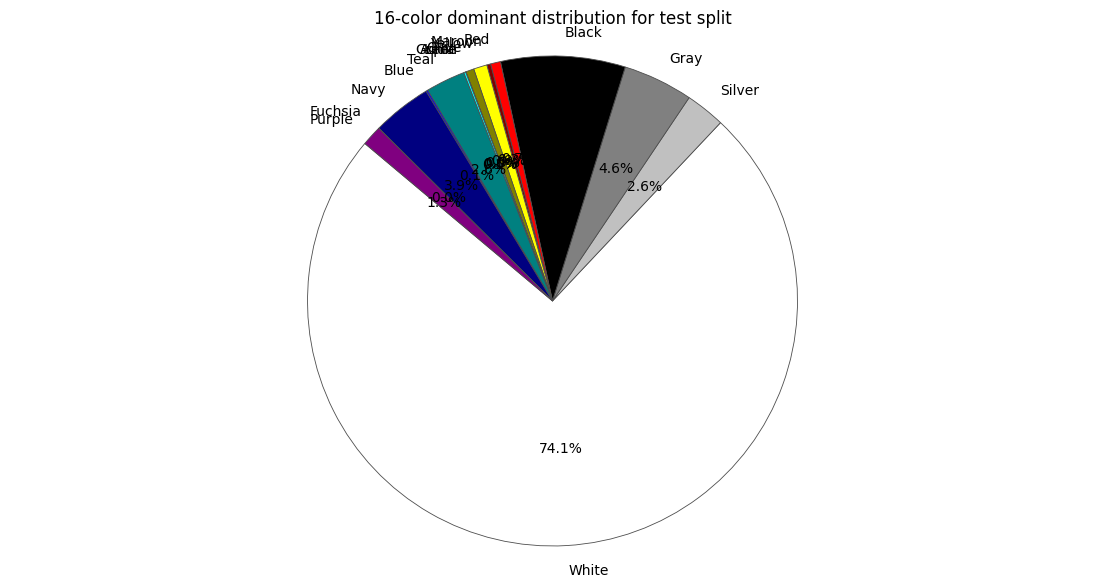

In [27]:
# Fixed 16-color RGB palette.
# https://en.wikipedia.org/wiki/Web_colors#Basic_colors
PALETTE = [
    ("White", (255, 255, 255)),
    ("Silver", (192, 192, 192)),
    ("Gray", (128, 128, 128)),
    ("Black", (0, 0, 0)),
    ("Red", (255, 0, 0)),
    ("Maroon", (128, 0, 0)),
    ("Yellow", (255, 255, 0)),
    ("Olive", (128, 128, 0)),
    ("Lime", (0, 255, 0)),
    ("Green", (0, 128, 0)),
    ("Aqua", (0, 255, 255)),
    ("Teal", (0, 128, 128)),
    ("Blue", (0, 0, 255)),
    ("Navy", (0, 0, 128)),
    ("Fuchsia", (255, 0, 255)),
    ("Purple", (128, 0, 128)),
]
PALETTE_RGB = np.array([rgb for _, rgb in PALETTE], dtype=np.int32)
PALETTE_MCOLORS = [tuple(v / 255 for v in rgb) for _, rgb in PALETTE]


def process_label_file(label_path):
    local_bins = Counter()
    image_path = label_path.with_suffix(".png")
    if not image_path.exists():
        return local_bins

    image = Image.open(image_path).convert("RGB")
    image_arr = np.array(image, dtype=np.uint8)

    with open(label_path) as f:
        lines = [line.strip() for line in f if line.strip()]

    for line in lines:
        class_id, x_center, y_center, width, height = line.split()
        x_center = float(x_center)
        y_center = float(y_center)
        width = float(width)
        height = float(height)

        left = int((x_center - width / 2) * image.width)
        right = int((x_center + width / 2) * image.width)
        top = int((y_center - height / 2) * image.height)
        bottom = int((y_center + height / 2) * image.height)

        left = max(0, min(image.width, left))
        right = max(0, min(image.width, right))
        top = max(0, min(image.height, top))
        bottom = max(0, min(image.height, bottom))

        if right <= left or bottom <= top:
            continue

        region = image_arr[top:bottom, left:right]
        pixels = region.reshape(-1, 3).astype(np.int32)

        diff = pixels[:, None, :] - PALETTE_RGB[None, :, :]
        dist2 = np.sum(diff * diff, axis=2)
        nearest_palette_idx = np.argmin(dist2, axis=1)

        palette_counts = np.bincount(nearest_palette_idx, minlength=len(PALETTE))
        dominant_idx = int(np.argmax(palette_counts))
        dominant_name, _ = PALETTE[dominant_idx]
        local_bins[dominant_name] += 1

    return local_bins


for split in SPLITS:
    color_bins = Counter({name: 0 for name, _ in PALETTE})
    label_paths = list((DATA_DIR / split).glob("*.txt"))
    max_workers = os.cpu_count() or 1

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(process_label_file, label_path)
            for label_path in label_paths
        ]
        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc=f"{split} images",
            leave=False,
            unit="image",
        ):
            color_bins.update(future.result())

    labels = [name for name, _ in PALETTE]
    sizes = [color_bins[name] for name in labels]
    total = sum(sizes)
    sizes = [size / total * 100 for size in sizes]

    wedge_colors = PALETTE_MCOLORS
    fig, ax = plt.subplots(figsize=(14, 7))
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=wedge_colors,
        autopct="%1.1f%%",
        startangle=140,
        wedgeprops={"edgecolor": "0.3", "linewidth": 0.6},
    )
    ax.set_title(f"16-color dominant distribution for {split} split")
    ax.axis("equal")
    plt.show()

### Show how many images have overlapping bboxes.

Processing train: 100%|██████████| 49538/49538 [02:48<00:00, 293.94file/s]


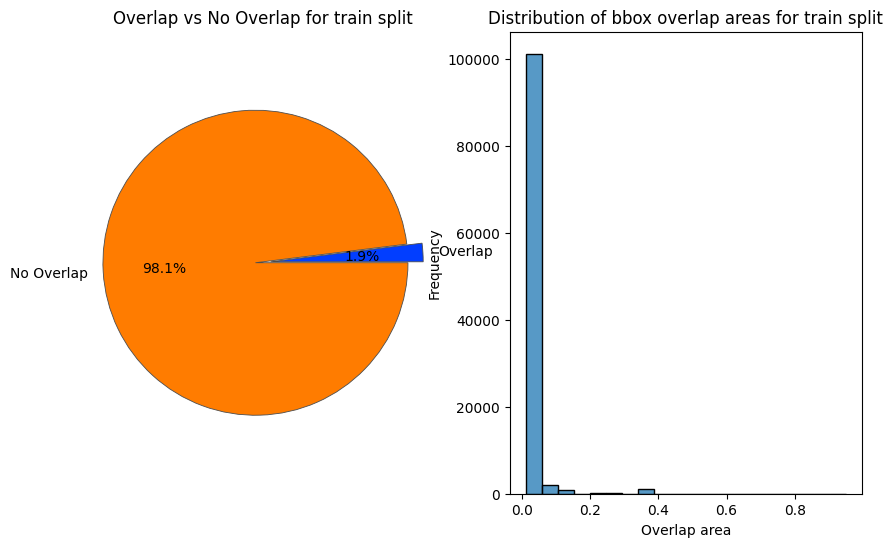

Processing val: 100%|██████████| 7158/7158 [00:18<00:00, 376.84file/s]


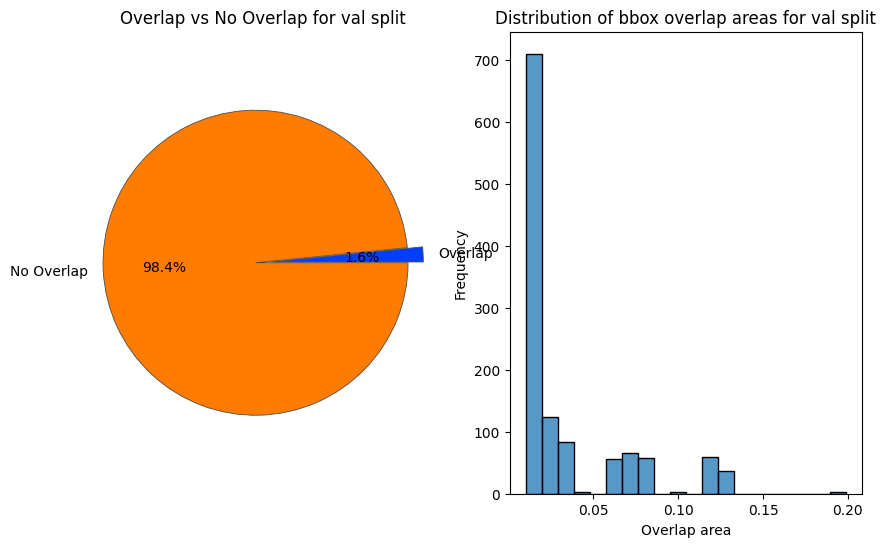

Processing test: 100%|██████████| 25251/25251 [01:04<00:00, 391.40file/s]


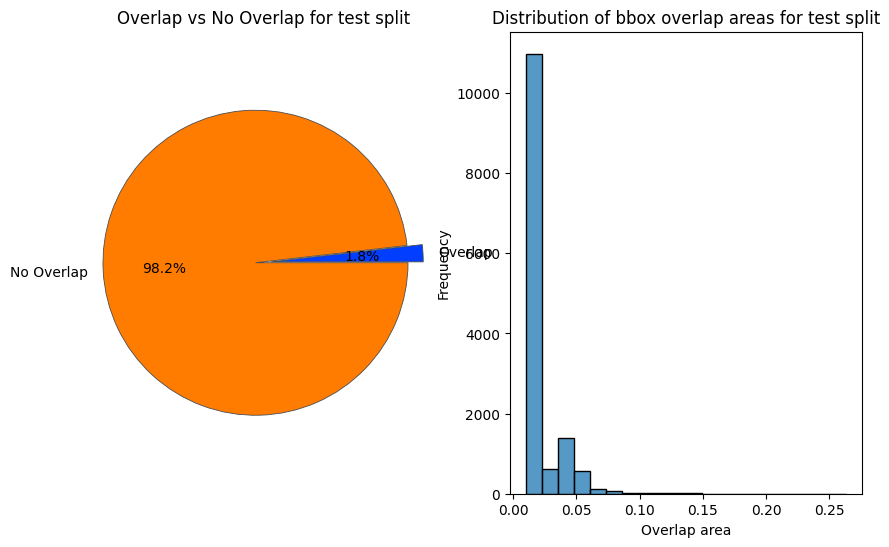

In [28]:
for split in SPLITS:
    overlap_bins = Counter()
    for label_path in tqdm(list((DATA_DIR / split).glob("*.txt")), desc=f"Processing {split}", unit="file"):
        with open(label_path) as f:
            lines = [line.strip() for line in f if line.strip()]
        bboxs = [BBox(
                    int(class_id),
                    float(x_center),
                    float(y_center),
                    float(width),
                    float(height),
                ) for line in lines for class_id, x_center, y_center, width, height in [line.split()]]
        for index, outer_bbox in enumerate(bboxs):
            outer_left = outer_bbox.x_center - outer_bbox.width / 2
            outer_right = outer_bbox.x_center + outer_bbox.width / 2
            outer_top = outer_bbox.y_center - outer_bbox.height / 2
            outer_bottom = outer_bbox.y_center + outer_bbox.height / 2
            for inner_bbox in bboxs[index + 1:]:
                inner_left = inner_bbox.x_center - inner_bbox.width / 2
                inner_right = inner_bbox.x_center + inner_bbox.width / 2
                inner_top = inner_bbox.y_center - inner_bbox.height / 2
                inner_bottom = inner_bbox.y_center + inner_bbox.height / 2

                overlap_x = max(0, min(outer_right, inner_right) - max(outer_left, inner_left))
                overlap_y = max(0, min(outer_bottom, inner_bottom) - max(outer_top, inner_top))
                overlap_area = overlap_x * overlap_y
                overlap_bins[overlap_area] += 1

    fig, axs = plt.subplots(figsize=(10, 6), nrows=1, ncols=2)
    overlap_count = sum(count for area, count in overlap_bins.items() if area > 0)
    no_overlap_count = sum(count for area, count in overlap_bins.items() if area == 0)
    colors = sns.color_palette('bright')
    axs[0].pie(
        [overlap_count, no_overlap_count],
        labels=["Overlap", "No Overlap"],
        colors=colors,
        autopct="%0.1f%%",
        explode=(0.1, 0),
        wedgeprops={"edgecolor": "0.3", "linewidth": 0.6},
    )
    axs[0].set_title(f"Overlap vs No Overlap for {split} split")
    axs[0].axis("equal")

    overlap_areas = [area for area in overlap_bins.elements() if area > 0.01]
    sns.histplot(overlap_areas, bins=20, kde=False, ax=axs[1])
    axs[1].set_title(f"Distribution of bbox overlap areas for {split} split")
    axs[1].set_xlabel("Overlap area")
    axs[1].set_ylabel("Frequency")
    plt.show()